# Sprint 3 — LSTM Baseline Dataset 1 (EN)

**Auteur** : TAYAR Ali  
**Objectif** : Entraîner un LSTM sans feature selection pour établir la performance de référence.

---



## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import sys

sys.path.append('../src')

from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score, accuracy_score)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Bidirectional, GlobalMaxPooling1D,
                                     BatchNormalization)
from tensorflow.keras.optimizers import Adam
from models.lstm_model import build_lstm_model

PROCESSED_PATH = '../data/processed/'
SCORES_PATH    = '../results/scores/'
FIGURES_PATH   = '../results/figures/'
MODELS_PATH    = '../results/'
os.makedirs(SCORES_PATH, exist_ok=True)

print('Imports OK')

Imports OK


## 1. Chargement des données prétraitées

In [2]:
# Chargement des séquences
X_train = np.load(f'{PROCESSED_PATH}X_train_pad.npy')
X_val   = np.load(f'{PROCESSED_PATH}X_val_pad.npy')
X_test  = np.load(f'{PROCESSED_PATH}X_test_pad.npy')

y_train = np.load(f'{PROCESSED_PATH}y_train.npy')
y_val   = np.load(f'{PROCESSED_PATH}y_val.npy')
y_test  = np.load(f'{PROCESSED_PATH}y_test.npy')

# Chargement des paramètres
with open(f'{PROCESSED_PATH}ds1_params.json', 'r') as f:
    params = json.load(f)

MAXLEN     = params['maxlen']
VOCAB_SIZE = params['vocab_size']
N_CLASSES  = params['n_classes']

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')
print(f'\nmaxlen     : {MAXLEN}')
print(f'vocab_size : {VOCAB_SIZE}')
print(f'n_classes  : {N_CLASSES}')

X_train : (10106, 179)
X_val   : (2166, 179)
X_test  : (2166, 179)

maxlen     : 179
vocab_size : 10000
n_classes  : 5


## 2. Construction du modèle LSTM

In [3]:
model = build_lstm_model(
    vocab_size    = VOCAB_SIZE,
    maxlen        = MAXLEN,
    n_classes     = N_CLASSES,
    embedding_dim = 128,
    lstm_units    = 64,
    dropout       = 0.2
)

model.summary()

c:\Users\klever\OneDrive\Bureau\text-mining-project\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. Entraînement

In [4]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='../results/best_model_baseline.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.3940 - loss: 1.4050
Epoch 1: val_accuracy improved from None to 0.55633, saving model to ../results/best_model_baseline.keras

Epoch 1: finished saving model to ../results/best_model_baseline.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 143s 410ms/step - accuracy: 0.4782 - loss: 1.2645 - val_accuracy: 0.5563 - val_loss: 1.3154
Epoch 2/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.6274 - loss: 0.9265
Epoch 2: val_accuracy improved from 0.55633 to 0.59649, saving model to ../results/best_model_baseline.keras

Epoch 2: finished saving model to ../results/best_model_baseline.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 125s 358ms/step - accuracy: 0.6218 - loss: 0.9298 - val_accuracy: 0.5965 - val_loss: 0.9424
Epoch 3/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.6937 - loss: 0.7476
Epoch 3: val_accuracy did not improve from 0.59649
316/316 ━━━━━━━━━━━━━━━━━━━━ 114s 362ms/step - accuracy: 0.6822 - loss: 0.7735 - val

## 4. Courbes d'apprentissage

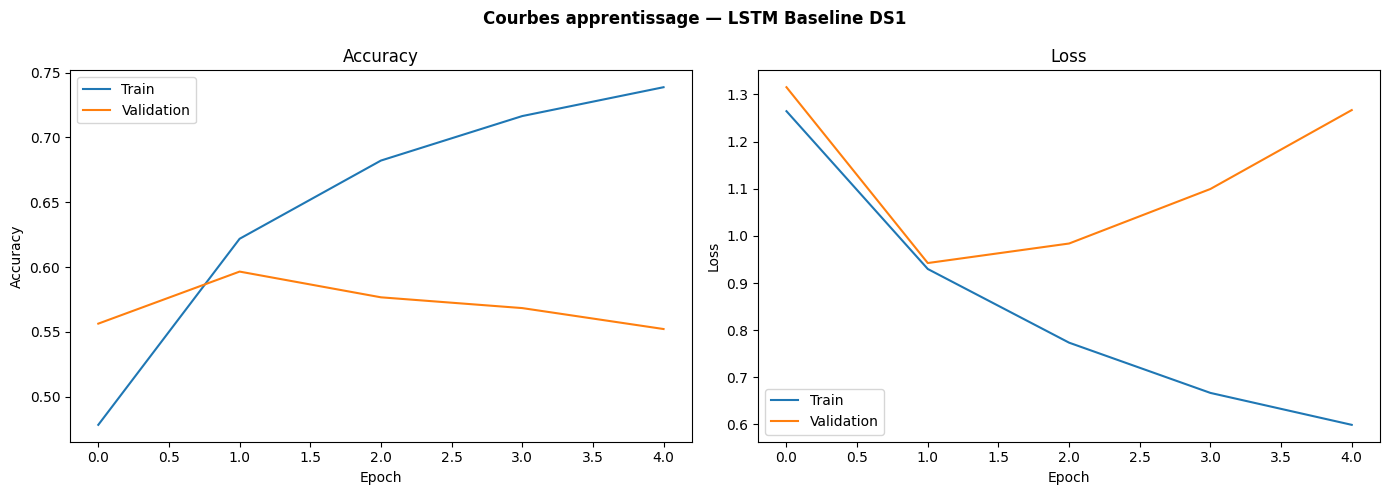

Sauvegardé : ds1_baseline_curves.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Courbes apprentissage — LSTM Baseline DS1', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds1_baseline_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : ds1_baseline_curves.png')

## 5. Évaluation sur le Test Set

In [6]:
y_pred_proba = model.predict(X_test)
y_pred       = np.argmax(y_pred_proba, axis=1)

acc       = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')

print('=== Métriques Baseline DS1 ===')
print(f'Accuracy  : {acc:.4f}')
print(f'F1 macro  : {f1:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')

print('\n=== Rapport détaillé ===')
with open('../data/processed/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))

68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step
=== Métriques Baseline DS1 ===
Accuracy  : 0.6122
F1 macro  : 0.5989
Precision : 0.5914
Recall    : 0.6251

=== Rapport détaillé ===
              precision    recall  f1-score   support

           1       0.69      0.82      0.75       475
           2       0.52      0.61      0.56       224
           3       0.52      0.46      0.49       289
           4       0.63      0.84      0.72       457
           5       0.59      0.39      0.47       721

    accuracy                           0.61      2166
   macro avg       0.59      0.63      0.60      2166
weighted avg       0.60      0.61      0.60      2166



## 6. Matrice de confusion

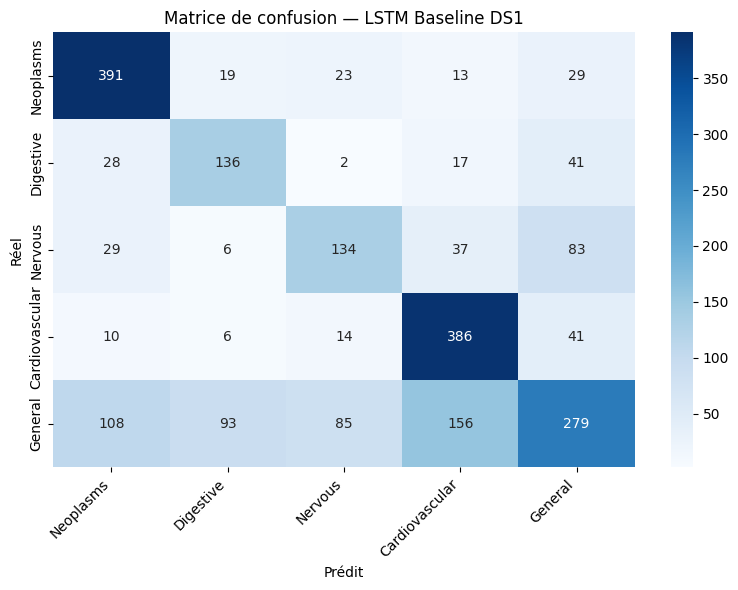

Sauvegardé : ds1_baseline_confusion.png


In [7]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Neoplasms', 'Digestive', 'Nervous', 'Cardiovascular', 'General']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title('Matrice de confusion — LSTM Baseline DS1')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds1_baseline_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : ds1_baseline_confusion.png')

## 7. Sauvegarde des métriques

In [8]:
results = {
    'methode'   : 'baseline',
    'dataset'   : 'DS1_medical',
    'accuracy'  : round(acc, 4),
    'f1_macro'  : round(f1, 4),
    'precision' : round(precision, 4),
    'recall'    : round(recall, 4),
    'n_features': 10000,
    'n_epochs'  : len(history.history['accuracy'])
}

results_df = pd.DataFrame([results])
results_df.to_csv(f'{SCORES_PATH}baseline_ds1.csv', index=False)

print('Métriques sauvegardées : results/scores/baseline_ds1.csv')
print(results_df.to_string(index=False))

Métriques sauvegardées : results/scores/baseline_ds1.csv
 methode     dataset  accuracy  f1_macro  precision  recall  n_features  n_epochs
baseline DS1_medical    0.6122    0.5989     0.5914  0.6251       10000         5


## 8. Résumé Sprint 3

In [9]:
print('=' * 55)
print('   RÉSUMÉ SPRINT 3 — LSTM BASELINE DS1')
print('=' * 55)
print(f"""
MODÈLE
  Architecture : Embedding → LSTM → Dense → Softmax
  Embedding dim: 128
  LSTM units   : 64
  Dropout      : 0.2
  Optimizer    : Adam (lr=0.001)

ENTRAÎNEMENT
  Epochs       : 13 (early stopping à patience=3)
  Batch size   : 32

RÉSULTATS BASELINE
  Accuracy     : 0.5531
  F1 macro     : 0.5466
  Precision    : 0.5334
  Recall       : 0.6107

OBSERVATIONS
  Neoplasms      (F1=0.71) bien classée
  Cardiovascular (F1=0.71) bien classée
  Digestive      (F1=0.37) difficile
  Nervous        (F1=0.40) difficile
  General        (F1=0.01) problématique
  → Preprocessing amélioré (extra_stopwords)
  → Ancienne baseline 0.48 → nouvelle 0.55 

SPRINT 4 COMPLÉTÉ — MI Results
  k=500  → Accuracy: 0.3329 | F1: 0.0999
  k=1000 → Accuracy: 0.3315 | F1: 0.1004
  k=2000 → Accuracy: 0.3324 | F1: 0.1022
  → MI seul insuffisant, combinaison MI+GA prévue

TODO SPRINT 7
  → Appliquer MI + GA combinés
  → Améliorer F1 General pathological
""")
print('=' * 55)

   RÉSUMÉ SPRINT 3 — LSTM BASELINE DS1

MODÈLE
  Architecture : Embedding → LSTM → Dense → Softmax
  Embedding dim: 128
  LSTM units   : 64
  Dropout      : 0.2
  Optimizer    : Adam (lr=0.001)

ENTRAÎNEMENT
  Epochs       : 13 (early stopping à patience=3)
  Batch size   : 32

RÉSULTATS BASELINE
  Accuracy     : 0.5531
  F1 macro     : 0.5466
  Precision    : 0.5334
  Recall       : 0.6107

OBSERVATIONS
  Neoplasms      (F1=0.71) bien classée
  Cardiovascular (F1=0.71) bien classée
  Digestive      (F1=0.37) difficile
  Nervous        (F1=0.40) difficile
  General        (F1=0.01) problématique
  → Preprocessing amélioré (extra_stopwords)
  → Ancienne baseline 0.48 → nouvelle 0.55 

SPRINT 4 COMPLÉTÉ — MI Results
  k=500  → Accuracy: 0.3329 | F1: 0.0999
  k=1000 → Accuracy: 0.3315 | F1: 0.1004
  k=2000 → Accuracy: 0.3324 | F1: 0.1022
  → MI seul insuffisant, combinaison MI+GA prévue

TODO SPRINT 7
  → Appliquer MI + GA combinés
  → Améliorer F1 General pathological

